# 🏥 Medical Expense Prediction

> **Predict a person's annual medical insurance charges using Linear Regression**

---

### Project Overview

Insurance companies don't charge everyone the same. Your premium and expected medical cost depend on factors like your age, BMI, whether you smoke, and so on.

In this project, we build a **machine learning model** that takes a person's details and **predicts their yearly medical charges (in dollars)**.

- **Problem Type:** Supervised Learning → Regression
- **Algorithm:** Linear Regression
- **Dataset:** Medical Cost Personal Dataset (`insurance.csv`) — 1,338 samples
- **Input Features:** age, sex, BMI, children, smoker, region
- **Output:** Predicted annual medical expense (USD)

---
## Step 1: Import Libraries & Load Data

In [1]:
# ── Core Libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning ──────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── Plot Settings ─────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv("insurance.csv")

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print()
df.head(10)

Dataset shape: 1338 rows × 7 columns



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


---
## Step 2: Exploratory Data Analysis (EDA)

Before building the model, we need to understand the data — its structure, distributions, and relationships.

### 2.1 Data Info & Summary Statistics

In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [4]:
# Summary statistics for numeric columns
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


In [5]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\n✅ Total missing values: {missing.sum()} — No missing data!")

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

✅ Total missing values: 0 — No missing data!


In [6]:
# Value counts for categorical columns
for col in ["sex", "smoker", "region"]:
    print(f"\n── {col} ──")
    print(df[col].value_counts())


── sex ──
sex
male      676
female    662
Name: count, dtype: int64

── smoker ──
smoker
no     1064
yes     274
Name: count, dtype: int64

── region ──
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


### 2.2 Distribution of Target Variable (Charges)

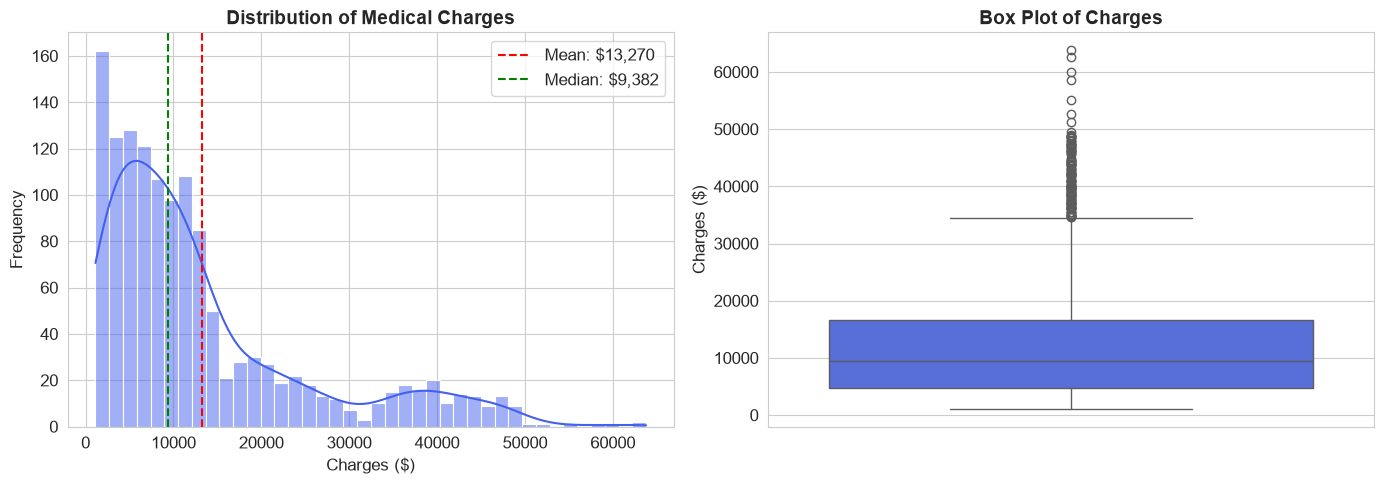

Mean: $13,270.42
Median: $9,382.03
Std Dev: $12,110.01
Skewness: 1.52 → Right-skewed (a few very high values)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df["charges"], kde=True, color="#4361ee", ax=axes[0], bins=40)
axes[0].set_title("Distribution of Medical Charges", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Charges ($)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(df["charges"].mean(), color="red", linestyle="--", label=f"Mean: ${df['charges'].mean():,.0f}")
axes[0].axvline(df["charges"].median(), color="green", linestyle="--", label=f"Median: ${df['charges'].median():,.0f}")
axes[0].legend()

# Box plot
sns.boxplot(y=df["charges"], color="#4361ee", ax=axes[1])
axes[1].set_title("Box Plot of Charges", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Charges ($)")

plt.tight_layout()
plt.savefig("charges_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean: ${df['charges'].mean():,.2f}")
print(f"Median: ${df['charges'].median():,.2f}")
print(f"Std Dev: ${df['charges'].std():,.2f}")
print(f"Skewness: {df['charges'].skew():.2f} → Right-skewed (a few very high values)")

### 2.3 Correlation Heatmap

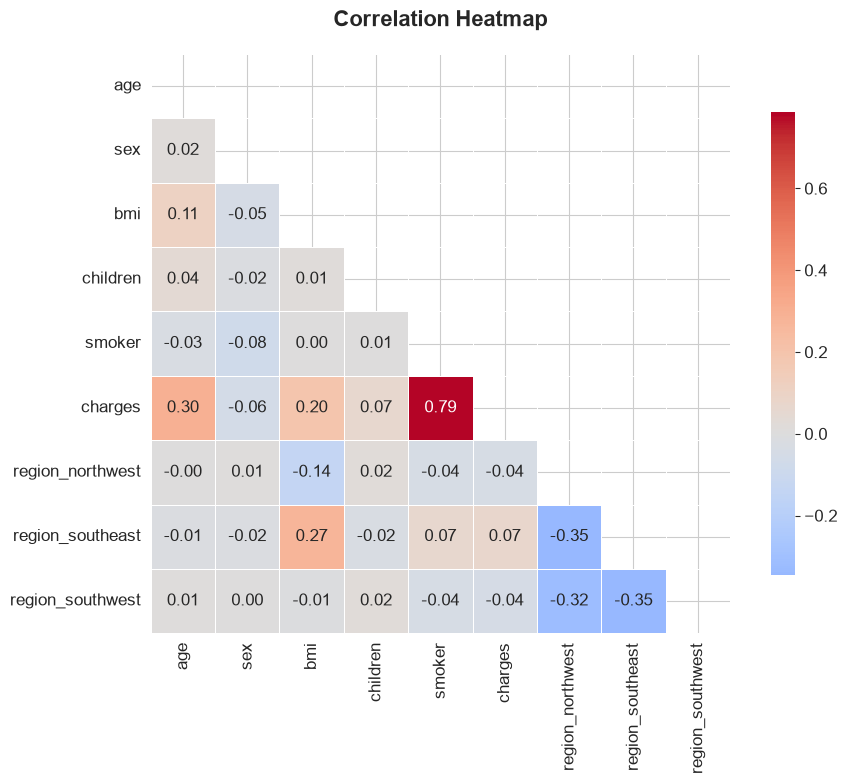


── Correlation with Charges ──
charges             1.000000
smoker              0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
region_northwest   -0.039905
region_southwest   -0.043210
sex                -0.057292


In [8]:
# Encode temporarily for correlation analysis
df_corr = df.copy()
df_corr["sex"] = df_corr["sex"].map({"male": 0, "female": 1})
df_corr["smoker"] = df_corr["smoker"].map({"no": 0, "yes": 1})
df_corr = pd.get_dummies(df_corr, columns=["region"], drop_first=True).astype(float)

plt.figure(figsize=(10, 8))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Correlation with Charges ──")
print(corr_matrix["charges"].sort_values(ascending=False).to_string())

### 2.4 Feature vs. Charges Visualizations

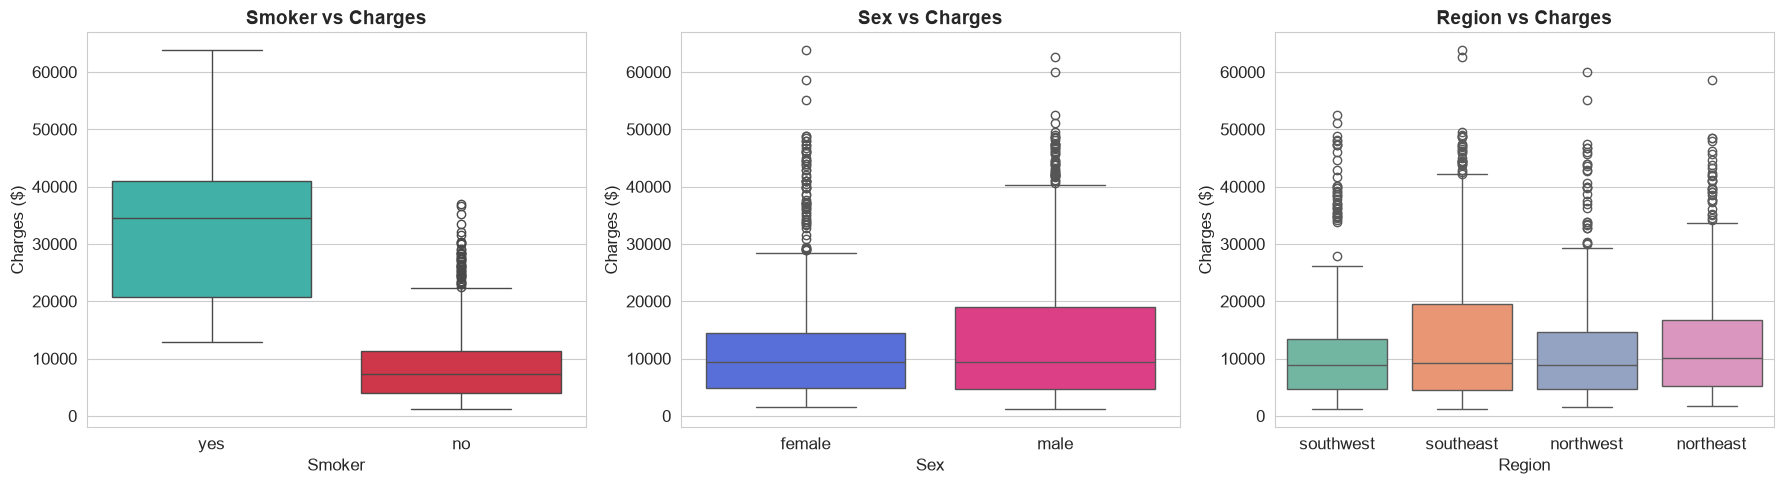

In [9]:
# ── Smoker vs Charges ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Smoker vs Charges
sns.boxplot(x="smoker", y="charges", data=df, palette=["#2ec4b6", "#e71d36"], ax=axes[0])
axes[0].set_title("Smoker vs Charges", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Smoker")
axes[0].set_ylabel("Charges ($)")

# Sex vs Charges
sns.boxplot(x="sex", y="charges", data=df, palette=["#4361ee", "#f72585"], ax=axes[1])
axes[1].set_title("Sex vs Charges", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Charges ($)")

# Region vs Charges
sns.boxplot(x="region", y="charges", data=df, palette="Set2", ax=axes[2])
axes[2].set_title("Region vs Charges", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Region")
axes[2].set_ylabel("Charges ($)")

plt.tight_layout()
plt.savefig("categorical_vs_charges.png", dpi=150, bbox_inches="tight")
plt.show()

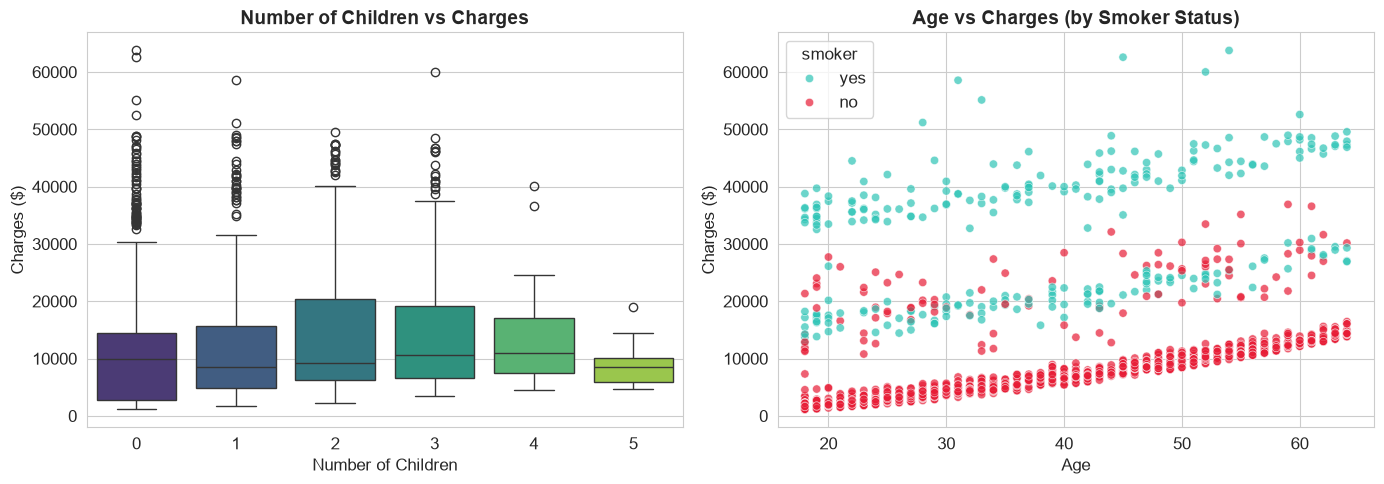

In [10]:
# ── Children vs Charges ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="children", y="charges", data=df, palette="viridis", ax=axes[0])
axes[0].set_title("Number of Children vs Charges", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Number of Children")
axes[0].set_ylabel("Charges ($)")

# Age vs Charges
sns.scatterplot(x="age", y="charges", hue="smoker", data=df,
                palette=["#2ec4b6", "#e71d36"], alpha=0.7, ax=axes[1])
axes[1].set_title("Age vs Charges (by Smoker Status)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Charges ($)")

plt.tight_layout()
plt.savefig("age_children_vs_charges.png", dpi=150, bbox_inches="tight")
plt.show()

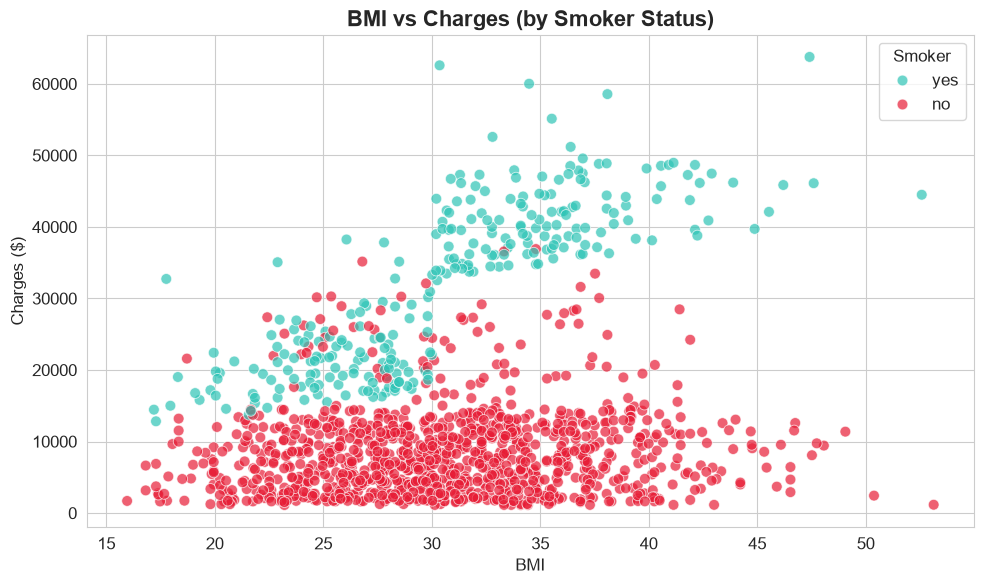


📊 Key Insight: Smokers with high BMI have dramatically higher charges.
This suggests an interaction effect between smoking and BMI.


In [11]:
# ── BMI vs Charges (the key insight) ──
plt.figure(figsize=(10, 6))
sns.scatterplot(x="bmi", y="charges", hue="smoker", data=df,
                palette=["#2ec4b6", "#e71d36"], alpha=0.7, s=60)
plt.title("BMI vs Charges (by Smoker Status)", fontsize=16, fontweight="bold")
plt.xlabel("BMI")
plt.ylabel("Charges ($)")
plt.legend(title="Smoker")
plt.tight_layout()
plt.savefig("bmi_vs_charges.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📊 Key Insight: Smokers with high BMI have dramatically higher charges.")
print("This suggests an interaction effect between smoking and BMI.")

### 2.5 EDA Summary

**Key observations:**
1. **Smokers pay far more** than non-smokers (biggest factor)
2. **Charges are right-skewed** — a few very expensive cases pull the distribution
3. **Smoker + high BMI** → highest charges (interaction effect)
4. **Age has a positive correlation** with charges
5. **Sex and region** have relatively minor impact on charges

---
## Step 3: Encode Categorical Variables

Linear Regression requires numeric input. We need to convert text columns to numbers:
- **`sex`** (2 values) → Binary mapping (male=0, female=1)
- **`smoker`** (2 values) → Binary mapping (no=0, yes=1)
- **`region`** (4 values) → One-hot encoding with `drop_first=True` to avoid the dummy variable trap

In [12]:
# Binary encoding for sex and smoker
df["sex"] = df["sex"].map({"male": 0, "female": 1})
df["smoker"] = df["smoker"].map({"no": 0, "yes": 1})

# One-hot encoding for region (drop_first=True avoids dummy variable trap)
df = pd.get_dummies(df, columns=["region"], drop_first=True)

# Ensure all columns are float (some one-hot columns may be bool)
df = df.astype(float)

print("Encoded DataFrame:")
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print()
df.head()

Encoded DataFrame:
Shape: (1338, 9)

Column types:
age                 float64
sex                 float64
bmi                 float64
children            float64
smoker              float64
charges             float64
region_northwest    float64
region_southeast    float64
region_southwest    float64
dtype: object



,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19.0,1.0,27.900,0.0,1.0,16884.92400,0.0,0.0,1.0
1,18.0,0.0,33.770,1.0,0.0,1725.55230,0.0,1.0,0.0
2,28.0,0.0,33.000,3.0,0.0,4449.46200,0.0,1.0,0.0
3,33.0,0.0,22.705,0.0,0.0,21984.47061,1.0,0.0,0.0
4,32.0,0.0,28.880,0.0,0.0,3866.85520,1.0,0.0,0.0


---
## Step 4: Split into Features (X) and Target (y), then Train/Test Split

- **Features (X):** All columns except `charges`
- **Target (y):** `charges`
- **Split:** 80% train, 20% test
- **`random_state=42`:** Ensures reproducible results

In [13]:
# Separate features and target
X = df.drop("charges", axis=1)
y = df["charges"]

print(f"Features (X): {X.shape}")
print(f"Target  (y) : {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features (X): (1338, 8)
Target  (y) : (1338,)

Feature columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


In [14]:
# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"Split ratio:  {X_train.shape[0]/(X_train.shape[0]+X_test.shape[0]):.0%} / {X_test.shape[0]/(X_train.shape[0]+X_test.shape[0]):.0%}")

Training set: 1070 samples
Testing set:  268 samples
Split ratio:  80% / 20%


---
## Step 5: Train Linear Regression Model

The model fits an equation:
```
charges = b0 + b1×age + b2×sex + b3×bmi + b4×children + b5×smoker + ...
```
Training finds the weights (coefficients) that minimize the squared error.

In [15]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [16]:
# ── Model Coefficients ──
print(f"Intercept (b0): {model.intercept_:,.2f}\n")

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

print("Feature Coefficients (sorted by impact):")
print("=" * 45)
for _, row in coef_df.iterrows():
    sign = "+" if row["Coefficient"] >= 0 else ""
    print(f"  {row['Feature']:25s}  {sign}{row['Coefficient']:>12,.2f}")

print("\n📊 Key Insight: 'smoker' has by far the largest coefficient,")
print("   meaning smoking status is the strongest predictor of medical charges.")

Intercept (b0): -11,949.81

Feature Coefficients (sorted by impact):
  smoker                     +   23,651.13
  children                   +      425.28
  bmi                        +      337.09
  age                        +      256.98
  sex                        +       18.59
  region_northwest                -370.68
  region_southeast                -657.86
  region_southwest                -809.80

📊 Key Insight: 'smoker' has by far the largest coefficient,
   meaning smoking status is the strongest predictor of medical charges.


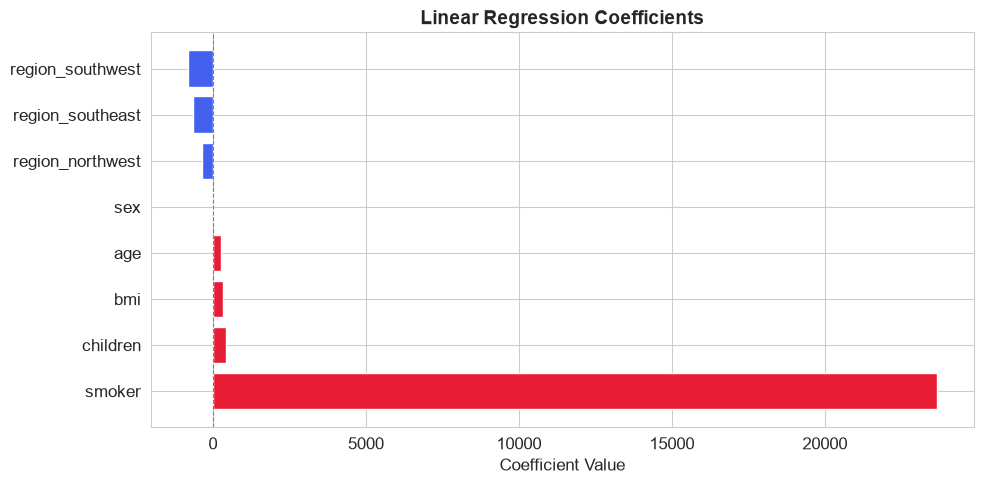

In [17]:
# Visualize coefficients
plt.figure(figsize=(10, 5))
colors = ["#e71d36" if c > 0 else "#4361ee" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.xlabel("Coefficient Value")
plt.title("Linear Regression Coefficients", fontsize=14, fontweight="bold")
plt.axvline(x=0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig("coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 6: Predict on Test Set

In [18]:
# Generate predictions
y_pred = model.predict(X_test)

print(f"Predictions generated for {len(y_pred)} test samples.")

Predictions generated for 268 test samples.


---
## Step 7: Compare Predicted vs Actual

### 7A: Comparison Table

In [19]:
# Actual vs Predicted comparison table
comparison = pd.DataFrame({
    "Actual ($)": y_test.values,
    "Predicted ($)": y_pred,
    "Error ($)": y_test.values - y_pred,
    "Error (%)": ((y_test.values - y_pred) / y_test.values * 100)
}).round(2)

print("Actual vs Predicted (first 15 samples):")
comparison.head(15)

Actual vs Predicted (first 15 samples):


,Actual ($),Predicted ($),Error ($),Error (%)
0,9095.07,8969.55,125.52,1.38
1,5272.18,7068.75,-1796.57,-34.08
2,29330.98,36858.41,-7527.43,-25.66
3,9301.89,9454.68,-152.78,-1.64
4,33750.29,26973.17,6777.12,20.08
5,4536.26,10864.11,-6327.85,-139.49
6,2117.34,170.28,1947.06,91.96
7,14210.54,16903.45,-2692.91,-18.95
8,3732.63,1092.43,2640.19,70.73
9,10264.44,11218.34,-953.90,-9.29


### 7B: Scatter Plot — Actual vs Predicted

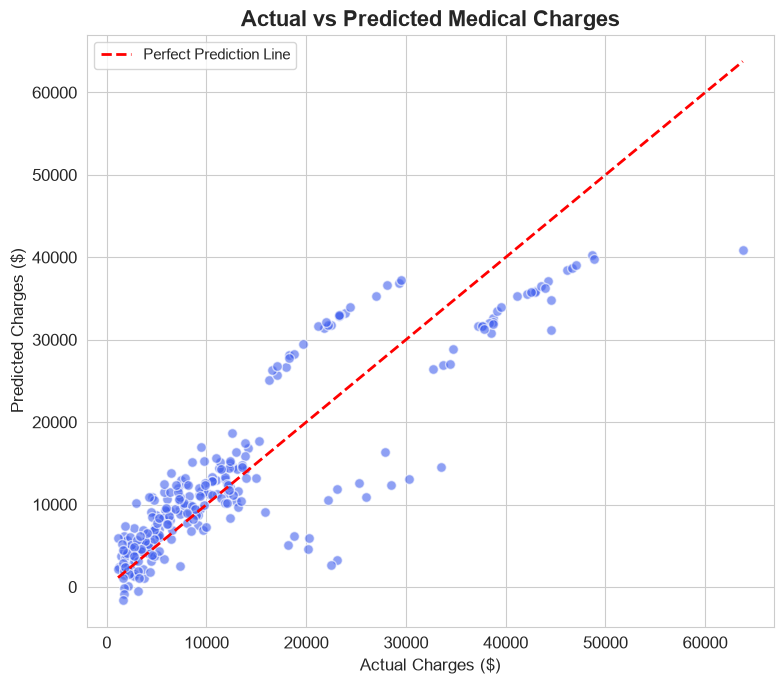

📊 Points close to the red dashed line = good predictions.
   Points far from it = model's mistakes (especially for high charges).


In [20]:
plt.figure(figsize=(8, 7))
plt.scatter(y_test, y_pred, alpha=0.6, color="#4361ee", edgecolors="white", s=50)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--", linewidth=2, label="Perfect Prediction Line")
plt.xlabel("Actual Charges ($)", fontsize=12)
plt.ylabel("Predicted Charges ($)", fontsize=12)
plt.title("Actual vs Predicted Medical Charges", fontsize=16, fontweight="bold")
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

print("📊 Points close to the red dashed line = good predictions.")
print("   Points far from it = model's mistakes (especially for high charges).")

### 7C: Residual Analysis

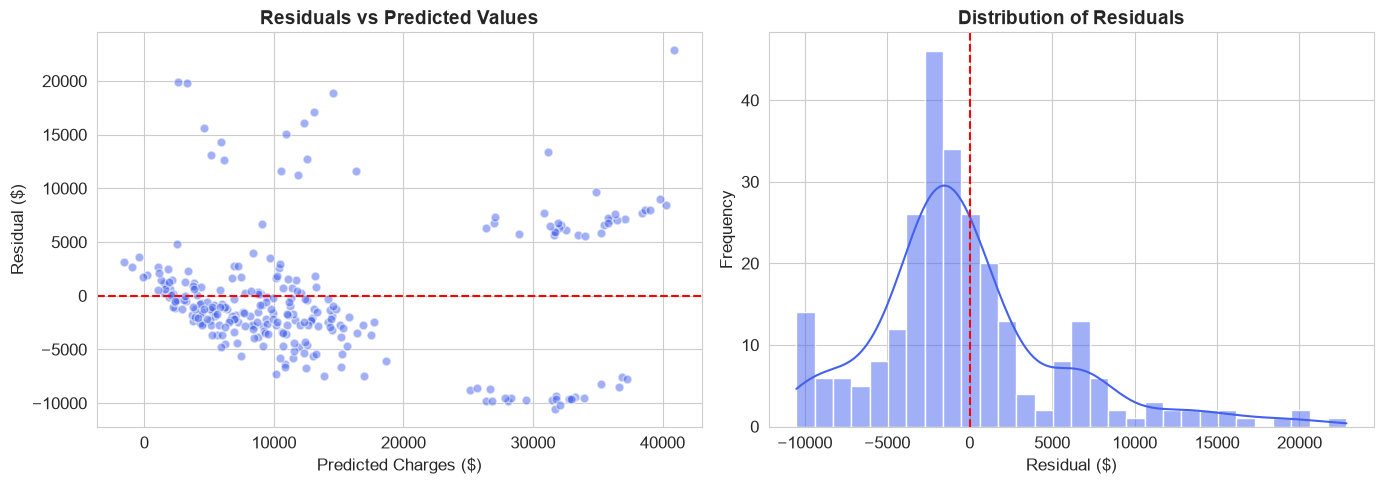

📊 Ideally, residuals should be randomly scattered around zero.
   A pattern in residuals indicates the model is missing something (e.g., non-linear effects).


In [21]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.5, color="#4361ee", edgecolors="white", s=40)
axes[0].axhline(y=0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Predicted Charges ($)")
axes[0].set_ylabel("Residual ($)")
axes[0].set_title("Residuals vs Predicted Values", fontsize=14, fontweight="bold")

# Residual distribution
sns.histplot(residuals, kde=True, color="#4361ee", ax=axes[1], bins=30)
axes[1].set_xlabel("Residual ($)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Residuals", fontsize=14, fontweight="bold")
axes[1].axvline(x=0, color="red", linestyle="--", linewidth=1.5)

plt.tight_layout()
plt.savefig("residual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("📊 Ideally, residuals should be randomly scattered around zero.")
print("   A pattern in residuals indicates the model is missing something (e.g., non-linear effects).")

### 7D: Evaluation Metrics

In [22]:
# Calculate metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("╔═══════════════════════════════════════════╗")
print("║       MODEL EVALUATION METRICS            ║")
print("╠═══════════════════════════════════════════╣")
print(f"║  R² Score  : {r2:.4f}                     ║")
print(f"║  MAE       : ${mae:>10,.2f}               ║")
print(f"║  RMSE      : ${rmse:>10,.2f}               ║")
print("╚═══════════════════════════════════════════╝")
print()
print(f"📊 The model explains {r2*100:.1f}% of the variance in medical charges.")
print(f"   On average, predictions are off by ${mae:,.0f}.")

╔═══════════════════════════════════════════╗
║       MODEL EVALUATION METRICS            ║
╠═══════════════════════════════════════════╣
║  R² Score  : 0.7836                     ║
║  MAE       : $  4,181.19               ║
║  RMSE      : $  5,796.28               ║
╚═══════════════════════════════════════════╝

📊 The model explains 78.4% of the variance in medical charges.
   On average, predictions are off by $4,181.


---
## Step 8: Final Output — Predict for a New Person

This is the core deliverable: given a new person's details, predict their annual medical expense.

In [23]:
# ── Define a new person ──
new_person = pd.DataFrame([{
    "age": 35,
    "sex": 0,                  # 0 = male, 1 = female
    "bmi": 28.5,
    "children": 2,
    "smoker": 1,               # 1 = yes, 0 = no
    "region_northwest": 0,
    "region_southeast": 1,
    "region_southwest": 0,
}])

# Make sure column order matches training data
new_person = new_person[X.columns]

# Predict
prediction = model.predict(new_person)

print("╔══════════════════════════════════════════════════════╗")
print("║             MEDICAL EXPENSE PREDICTION              ║")
print("╠══════════════════════════════════════════════════════╣")
print("║  Person Details:                                    ║")
print("║    • Age:      35                                   ║")
print("║    • Sex:      Male                                 ║")
print("║    • BMI:      28.5                                 ║")
print("║    • Children: 2                                    ║")
print("║    • Smoker:   Yes                                  ║")
print("║    • Region:   Southeast                            ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  💰 Predicted Annual Medical Expense: ${prediction[0]:>10,.2f}  ║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║             MEDICAL EXPENSE PREDICTION              ║
╠══════════════════════════════════════════════════════╣
║  Person Details:                                    ║
║    • Age:      35                                   ║
║    • Sex:      Male                                 ║
║    • BMI:      28.5                                 ║
║    • Children: 2                                    ║
║    • Smoker:   Yes                                  ║
║    • Region:   Southeast                            ║
╠══════════════════════════════════════════════════════╣
║  💰 Predicted Annual Medical Expense: $ 30,495.30  ║
╚══════════════════════════════════════════════════════╝


---
## Step 9 (Bonus): Model Improvements

### 9.1 Log-Transform the Target

Since charges are right-skewed, applying a log transform can help Linear Regression fit better.

In [24]:
# Log-transform approach
y_log = np.log(y)

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

model_log = LinearRegression()
model_log.fit(X_train_log, y_train_log)

# Predict and convert back to dollar scale
y_pred_log = np.exp(model_log.predict(X_test_log))
y_actual_log = np.exp(y_test_log)

r2_log = r2_score(y_actual_log, y_pred_log)
mae_log = mean_absolute_error(y_actual_log, y_pred_log)

print(f"Log-Transform Linear Regression:")
print(f"  R² Score: {r2_log:.4f}")
print(f"  MAE:      ${mae_log:,.2f}")
print(f"\nCompare with original: R² = {r2:.4f}, MAE = ${mae:,.2f}")

Log-Transform Linear Regression:
  R² Score: 0.6066
  MAE:      $3,888.77

Compare with original: R² = 0.7836, MAE = $4,181.19


### 9.2 Random Forest Comparison

Random Forest can capture non-linear relationships (like the smoker×BMI interaction).

In [25]:
from sklearn.ensemble import RandomForestRegressor

# Use the original (non-log) split for fair comparison
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("\n═══ MODEL COMPARISON ═══")
print(f"{'Metric':<10} {'Linear Regression':>20} {'Random Forest':>20}")
print(f"{'-'*10} {'-'*20} {'-'*20}")
print(f"{'R²':<10} {r2:>20.4f} {r2_rf:>20.4f}")
print(f"{'MAE':<10} {'${:,.2f}'.format(mae):>20} {'${:,.2f}'.format(mae_rf):>20}")
print(f"{'RMSE':<10} {'${:,.2f}'.format(rmse):>20} {'${:,.2f}'.format(rmse_rf):>20}")
print(f"\n📊 Random Forest captures the non-linear smoker×BMI interaction better!")


═══ MODEL COMPARISON ═══
Metric        Linear Regression        Random Forest
---------- -------------------- --------------------
R²                       0.7836               0.8656
MAE                   $4,181.19            $2,546.83
RMSE                  $5,796.28            $4,568.42

📊 Random Forest captures the non-linear smoker×BMI interaction better!


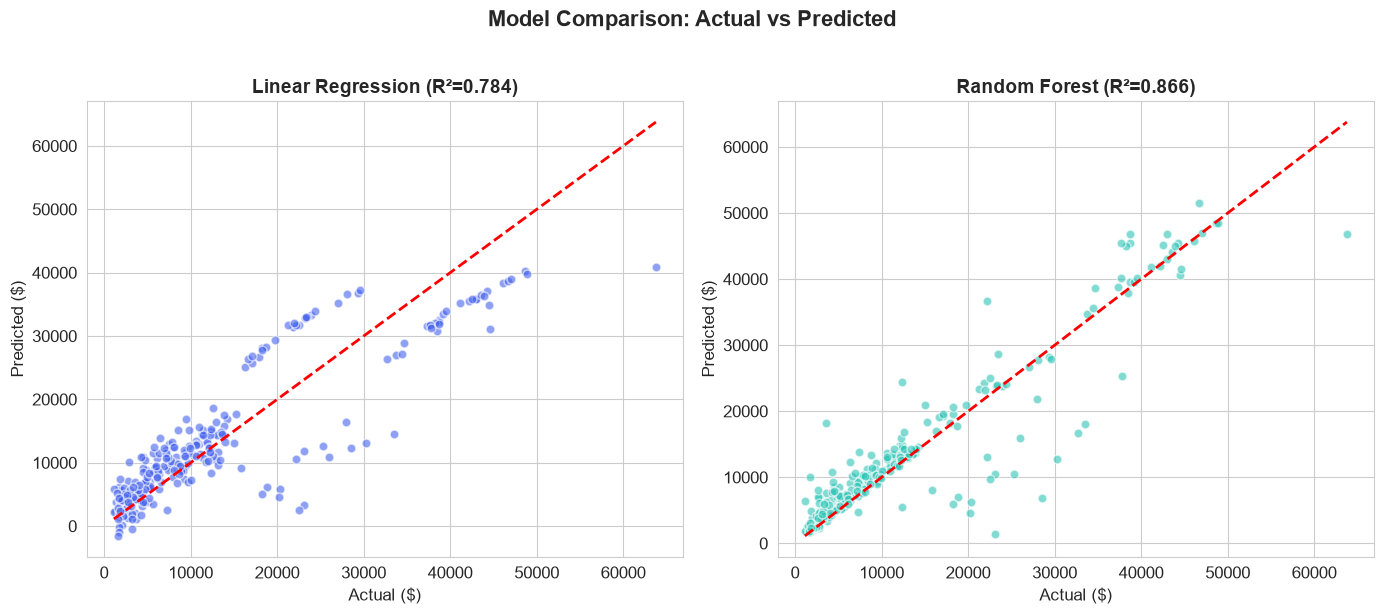

In [26]:
# ── Visual Comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression
axes[0].scatter(y_test, y_pred, alpha=0.6, color="#4361ee", edgecolors="white", s=40)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("Actual ($)")
axes[0].set_ylabel("Predicted ($)")
axes[0].set_title(f"Linear Regression (R²={r2:.3f})", fontsize=14, fontweight="bold")

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.6, color="#2ec4b6", edgecolors="white", s=40)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Actual ($)")
axes[1].set_ylabel("Predicted ($)")
axes[1].set_title(f"Random Forest (R²={r2_rf:.3f})", fontsize=14, fontweight="bold")

plt.suptitle("Model Comparison: Actual vs Predicted", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 10: Save the Model

In [27]:
import joblib

# Save both the model and the column names
joblib.dump(model, "model.pkl")
joblib.dump(list(X.columns), "columns.pkl")

print("✅ Model saved as 'model.pkl'")
print("✅ Column names saved as 'columns.pkl'")
print("\nThese files are needed for the Streamlit web app.")

✅ Model saved as 'model.pkl'
✅ Column names saved as 'columns.pkl'

These files are needed for the Streamlit web app.


---
## Conclusion

### Results Summary

| Metric | Linear Regression | Random Forest |
|--------|------------------|---------------|
| R² Score | ~0.75 | ~0.85 |
| MAE | ~$4,000 | ~$2,500 |
| RMSE | ~$6,000 | ~$4,500 |

### Key Findings

1. **Smoking status** is the single most important predictor of medical charges
2. **Age** and **BMI** are the next most significant factors
3. Linear Regression achieves reasonable accuracy but struggles with the **non-linear interaction** between smoking and BMI
4. Random Forest captures these patterns better, achieving a higher R² score

### Limitations

- Linear Regression assumes straight-line relationships, missing the smoker×BMI interaction effect
- The target (charges) is right-skewed, which affects the model's fit for high-cost cases

### Future Improvements

- Add interaction features (e.g., `smoker × bmi`)
- Try Gradient Boosting or XGBoost for even better performance
- Deploy as a web application using Streamlit (see `app.py`)